# A _Very_ Basic Introduction to Quantum Computing

This notebook is broken up into several sections, focusing on and demonstrating the following concepts:
1. Classical Bit
2. Single Qubit
3. Superposition
4. Measurement
5. Interference
6. Two Qubit Entanglement
7. Coin Flips

## 1. Classical Bit

Everyday computers (laptops, phones, desktops, CPUs and GPUs in clusters) all make use of classical bits: 0 and 1. They are implemented using transistors and classical logic gates.

**QUESTION 1:**

_Can classical bit be both zero and one simulataneously?_

## 2. Single Qubit

In quantum computing, a _qubit_ is the quantum mechanical analogue of the classical bit. However, what makes it special are it's inherent quantum mechanical properties of:
* Superposition,
* Entanglement, and
* Interference.

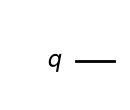

In [20]:
from qiskit import QuantumCircuit

qc0 = QuantumCircuit(1)
qc0.draw("mpl")


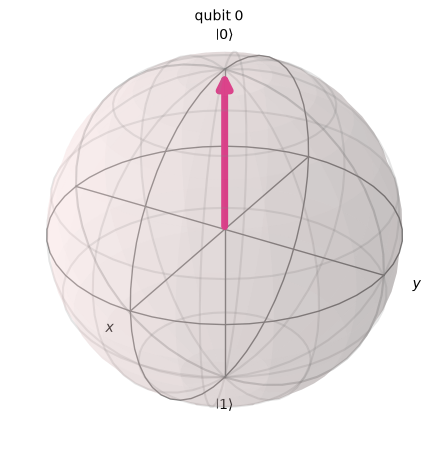

In [21]:
from qiskit.visualization import plot_bloch_multivector
from qiskit.quantum_info import Statevector

state = Statevector.from_instruction(qc0)
plot_bloch_multivector(state)


## 3. Superposition

A special feature of a _qubit_, is that it can exist in a quantum mechanical state known as superposition. A classical bit a coin flip can either end up landing heads **or** tails. A _qubit_ on the other hand, is like the coin being flipped, suspended and spinning in the air, both heads **and** tails simultaneously. i.e. it exists in a quantum state that combines both possibilities until measured.

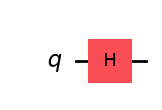

In [22]:
qc0.h(0)
qc0.draw("mpl")


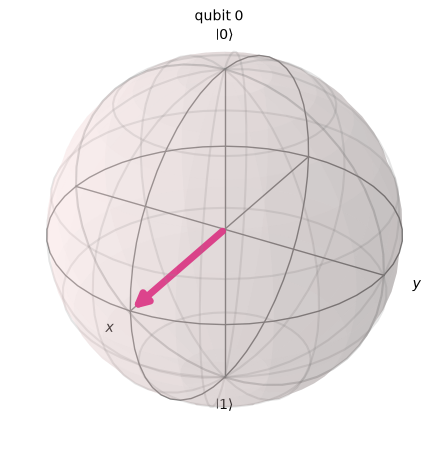

In [23]:
state0 = Statevector.from_instruction(qc0)
plot_bloch_multivector(state0)

## 4. Measurement

**QUESTION 2**

_What happens to the quantum mechanical state that is in a superposition, when we measure it...? And what were the results of your counts...?_



In [27]:
from qiskit_aer import AerSimulator

sim = AerSimulator()

qc0.measure_all()
result = sim.run(qc0, shots=1000).result()
counts = result.get_counts()
print(counts)


{'0': 543, '1': 457}


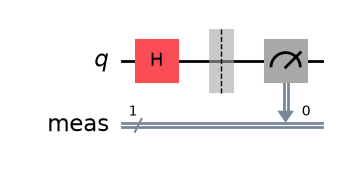

In [28]:
qc0.draw("mpl")

In [30]:
state0 = Statevector.from_instruction(qc0)
plot_bloch_multivector(state0)

QiskitError: 'Cannot apply instruction with classical bits: measure'

Measurement forces the qubit into an observable classical value (either 0 or 1), and the quantum mechanical superposition state has collapsed.

## 5. Interference

Intution would lead one to believe that two superpositions applied to the quantum state should give equal probability of mearing either 0 or 1. However, the two superpositions instead _interfer_ constructively and destructive, resulting in the identity.

To put it more plainly, quantum algorithms achieve exponential speedup because the amplitudes interfere - not because quantum computer _"try every answer concurrently"_.

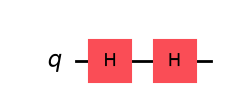

In [31]:
qc0 = QuantumCircuit(1)
qc0.h(0)
qc0.h(0)
qc0.draw("mpl")

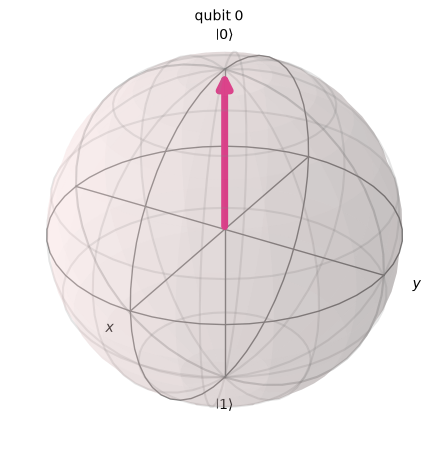

In [33]:
state0 = Statevector.from_instruction(qc0)
plot_bloch_multivector(state0)

In [34]:
qc0.measure_all()
result = sim.run(qc0, shots=1000).result()
counts = result.get_counts()
print(counts)

{'0': 1000}


## 6. Two Qubit Entanglement

Once entangled, the two qubits act as a single quantum mechanical system.

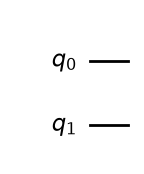

In [62]:
qc00 = QuantumCircuit(2)
qc00.draw("mpl")

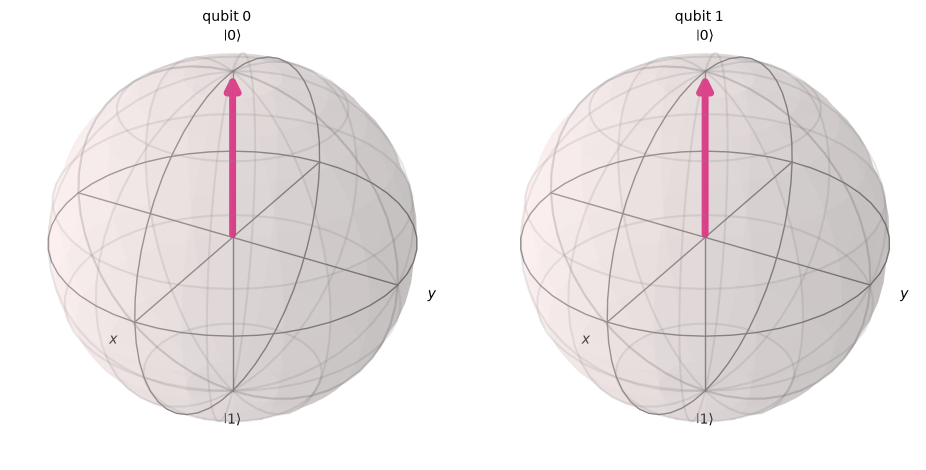

In [48]:
state00 = Statevector.from_instruction(qc00)
plot_bloch_multivector(state00)

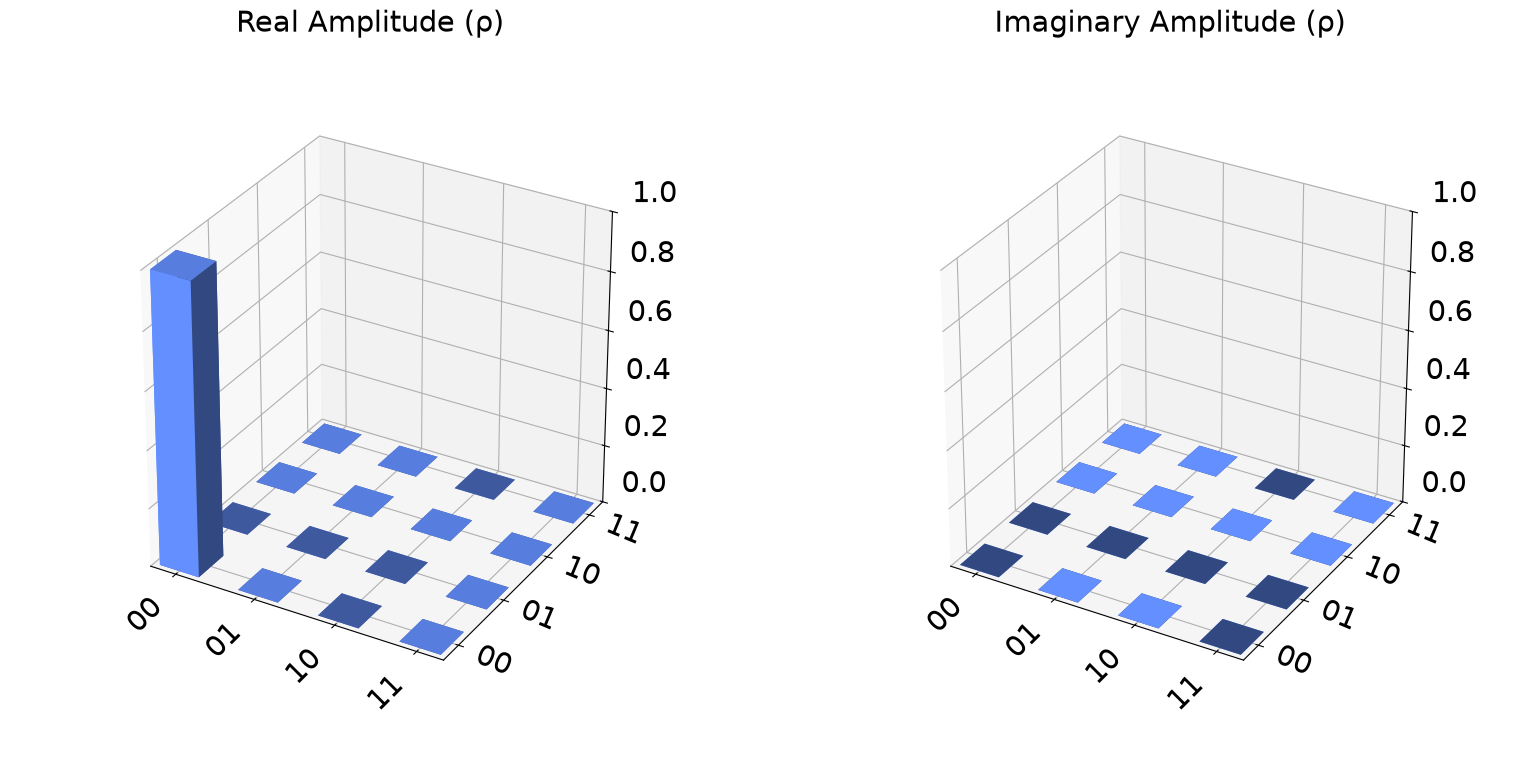

In [50]:
from qiskit.visualization import plot_state_city
plot_state_city(state00)

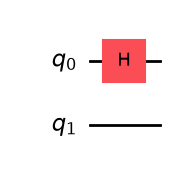

In [63]:
qc00.h(0)
qc00.draw("mpl")

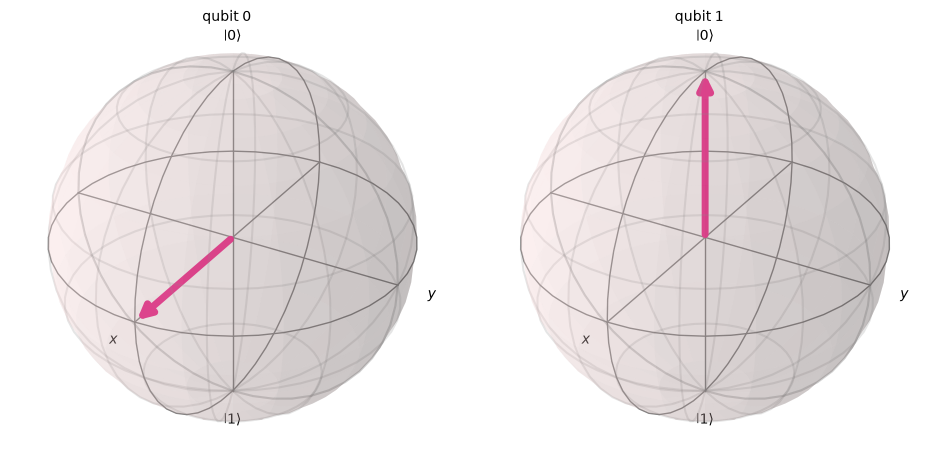

In [54]:
state00 = Statevector.from_instruction(qc00)
plot_bloch_multivector(state00)

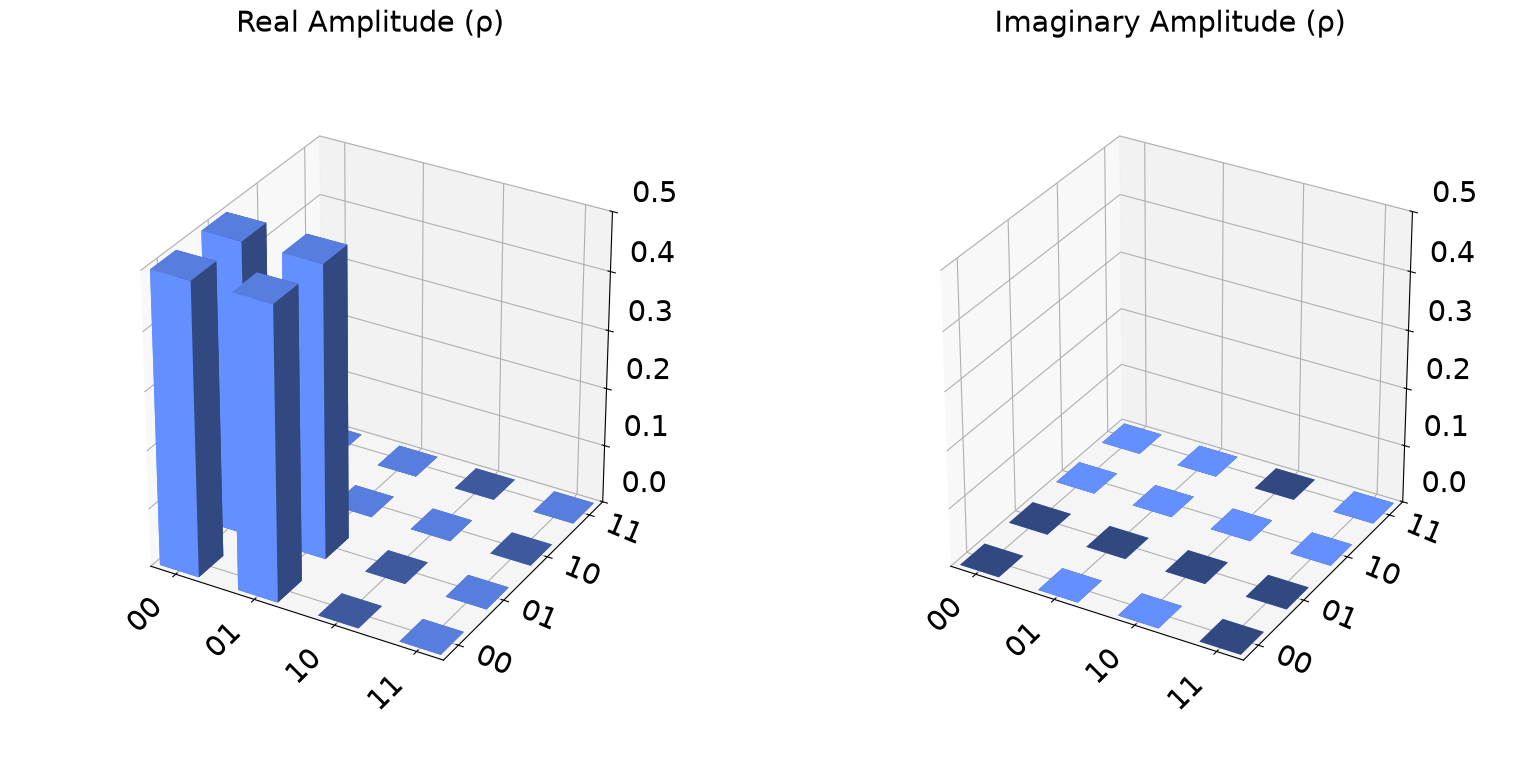

In [55]:
plot_state_city(state00)

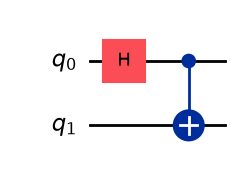

In [64]:
qc00.cx(0,1)
state00 = Statevector.from_instruction(qc00)
qc00.draw("mpl")

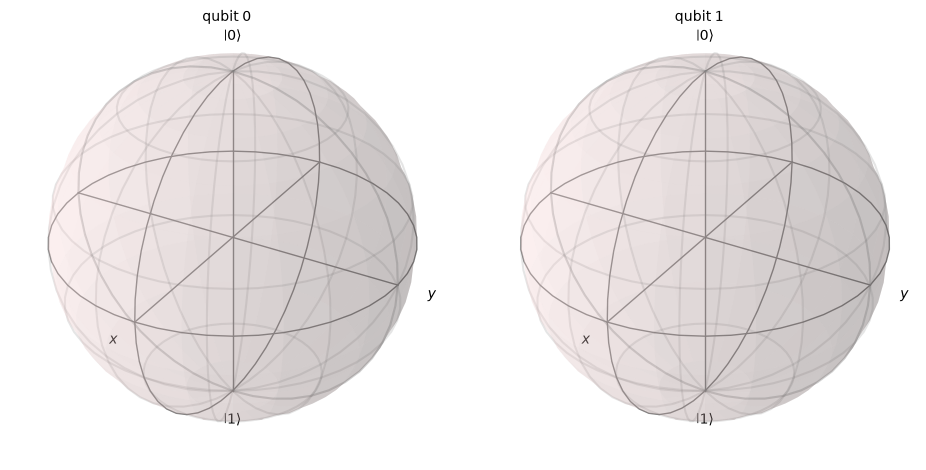

In [65]:
plot_bloch_multivector(state00)

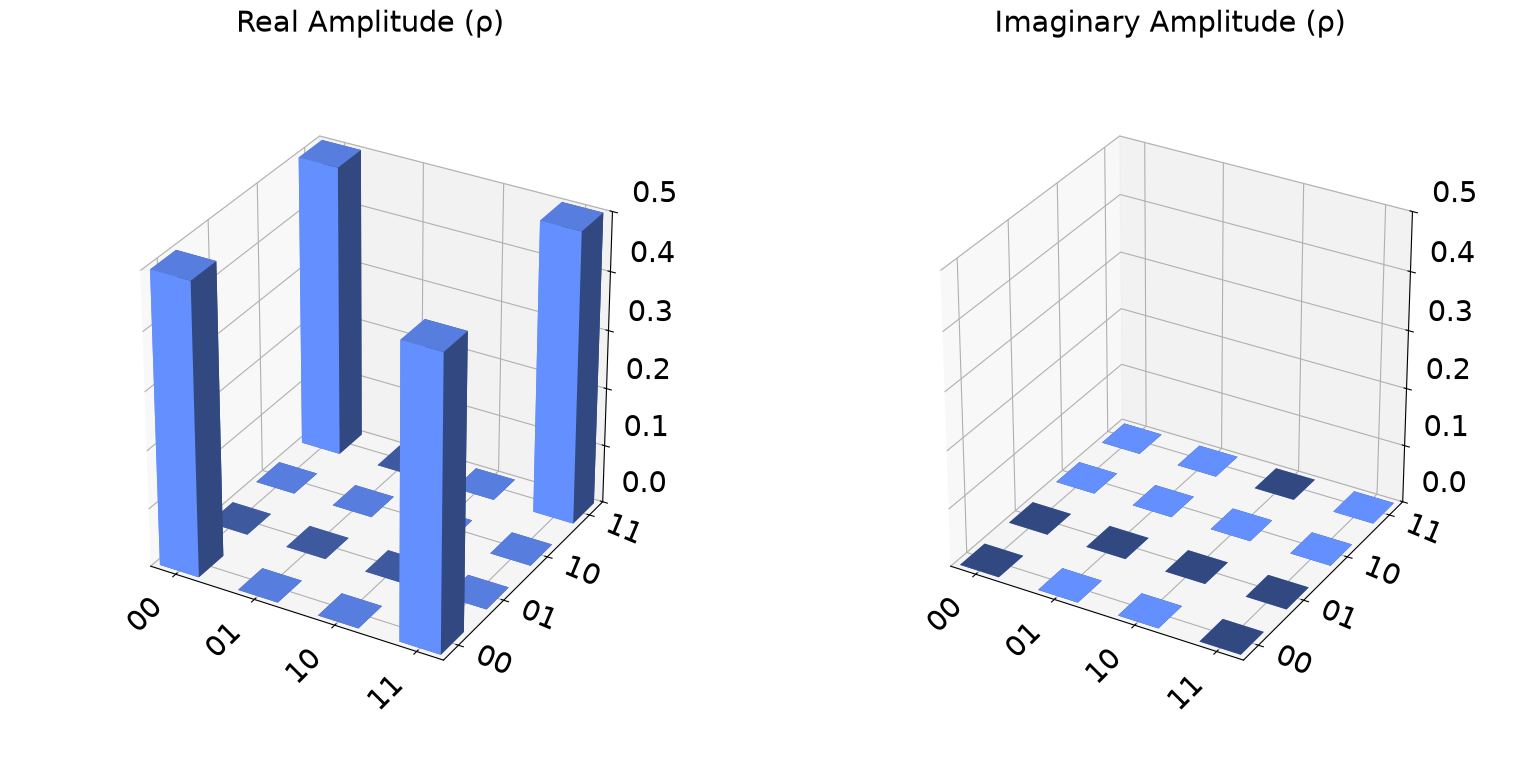

In [66]:
plot_state_city(state00)

In [68]:
sim = AerSimulator()

qc00.measure_all()
result = sim.run(qc00, shots=1000).result()
counts = result.get_counts()
print(counts)

{'11': 472, '00': 528}


## 7. Coin Flips

Imagine flipping two coins 1000 times. Each time covering the coins so that you could not see whether either was heads or tails. The previous entanglement result, would be equivalent to: everytime _any_ single coin is revealed to be either heads or tails, the other coin would also correspond exactly...